In [43]:
# CIL imports
from cil.framework import ImageData, ImageGeometry, BlockDataContainer
from cil.framework import AcquisitionGeometry, AcquisitionData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.algorithms import GD

from cil.optimisation.operators import BlockOperator, GradientOperator,\
                                       GradientOperator, IdentityOperator, DiagonalOperator

from cil.optimisation.functions import L1Norm, LeastSquares, TotalVariation 


In [44]:
# Set logging level for CIL processors:
logging.basicConfig(level=logging.WARNING)
cil_log_level = logging.getLogger('cil.processors')
cil_log_level.setLevel(logging.INFO)

In [45]:
# Setting background defaults

cmap = "rainbow"
device = "cpu"

# number of pixels and number of angles
n_pixels = 50
n_angles = 40

In [46]:
# Angles
angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

# Setup acquisition geometry
ag = AcquisitionGeometry.create_Parallel2D()\
                            .set_angles(angles)\
                            .set_panel(n_pixels, pixel_size=1/n_pixels)

# Setup image geometry
ig = ImageGeometry(voxel_num_x=n_pixels, 
                   voxel_num_y=n_pixels, 
                   voxel_size_x=1/n_pixels, 
                   voxel_size_y=1/n_pixels)

# Get phantom
phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


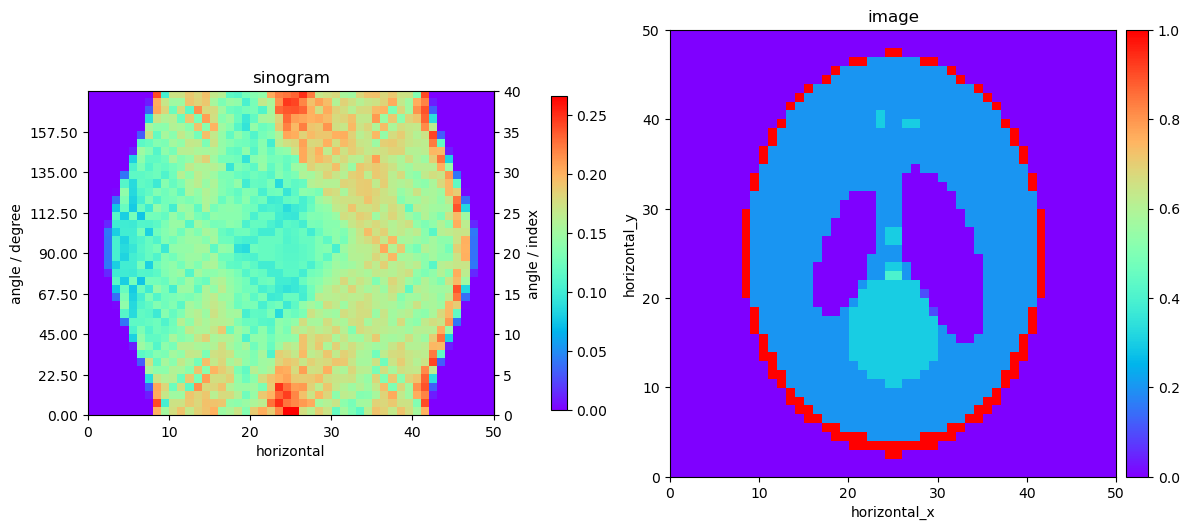

In [47]:
# Show the picture of the example that will be worked with in this code

# Create projection operator using Astra-Toolbox.
A = ProjectionOperator(ig, ag, device)

# Create an acquisition data (numerically)
sino = A.direct(phantom)

show2D([sino, phantom], ['sinogram', 'image'], cmap=cmap, size=(12,6))

Trying out the block framework

In [48]:
print(phantom.shape)
print(ig.shape)

print(type(A))

(50, 50)
(50, 50)
<class 'cil.plugins.astra.operators.ProjectionOperator.ProjectionOperator_ag'>


In [49]:
L = IdentityOperator(ig)
alpha = 100000

operator_block = BlockOperator(A, alpha*L)

zero_data = L.range.allocate(0)

data_block = BlockDataContainer(sino, zero_data)

x0 = ig.allocate(0)
print(type(x0))

print(np.size(x0))

print(n_pixels**2)

lets_us_pray = np.identity(n_pixels)

x0 = ig.allocate(lets_us_pray)

<class 'cil.framework.image_data.ImageData'>
2500
2500


In [50]:
cgls_onenorm = CGLS(initial=x0, operator=operator_block, data=data_block, update_objective_interval=10)

cgls_onenorm.run(1000, verbose=1)

  0%|          | 0/1000 [00:00<?, ?it/s]

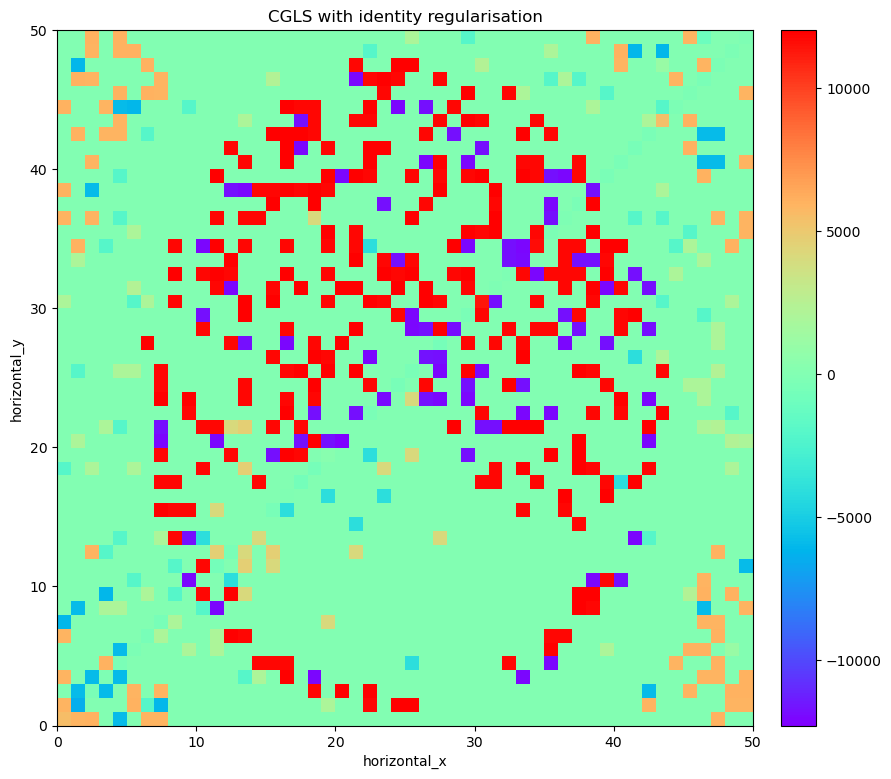

<class 'cil.framework.image_data.ImageData'>
<class 'cil.framework.image_data.ImageData'>


In [51]:
show2D([cgls_onenorm.solution], ['CGLS with identity regularisation'], cmap=cmap)

print(type(cgls_onenorm.solution))

x = 1/cgls_onenorm.solution
print(type(x))


<class 'cil.framework.image_data.ImageData'> <class 'cil.framework.image_geometry.ImageGeometry'>


  0%|          | 0/1000 [00:00<?, ?it/s]

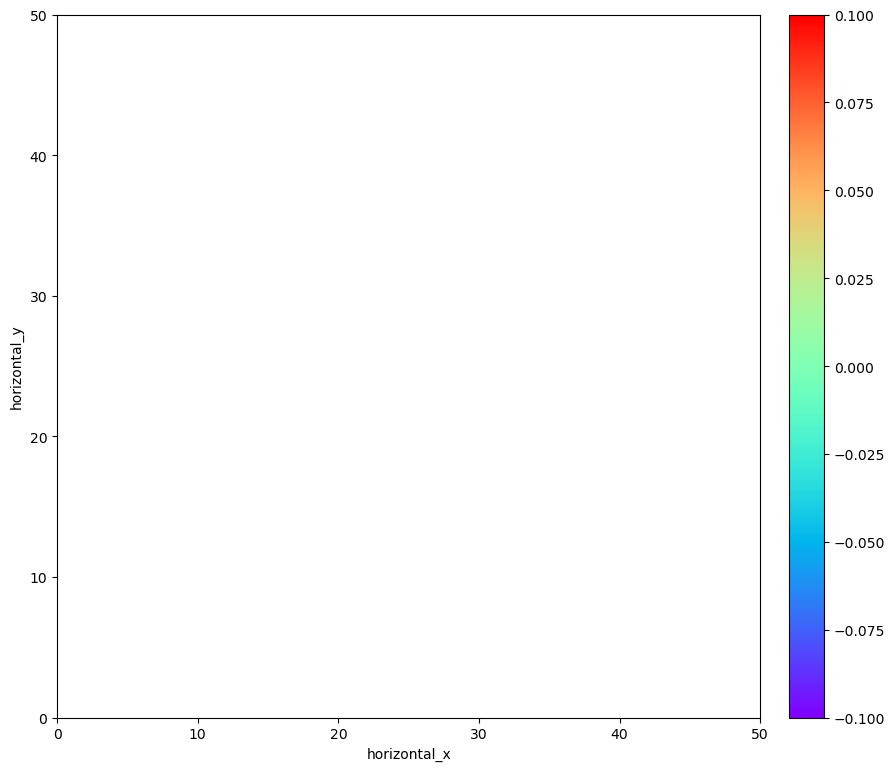

In [59]:
wk = cgls_onenorm.solution

w = wk**(-1/2)

print(type(w), type(ig))


w_doesitwork = DiagonalOperator(w)
# w_doesitwork = ProjectionOperator(w, ag, device)


operator_block = BlockOperator(A, alpha*w_doesitwork)
zero_data = ig.allocate(0)
data_block = BlockDataContainer(sino, zero_data)

new_cgls = CGLS(initial=x0, operator=operator_block, data=data_block, update_objective_interval=10)


new_cgls.run(1000, verbose=1)

show2D(new_cgls.solution, cmap=cmap)

In [53]:
f = LeastSquares(operator_block, data_block)

myGD_block = GD(initial=x0, 
             f=f, 
             step_size=5, 
             update_objective_interval=10)

myGD_block.run(500, verbose=1)
myGD_block = myGD_block.solution

  0%|          | 0/500 [00:00<?, ?it/s]

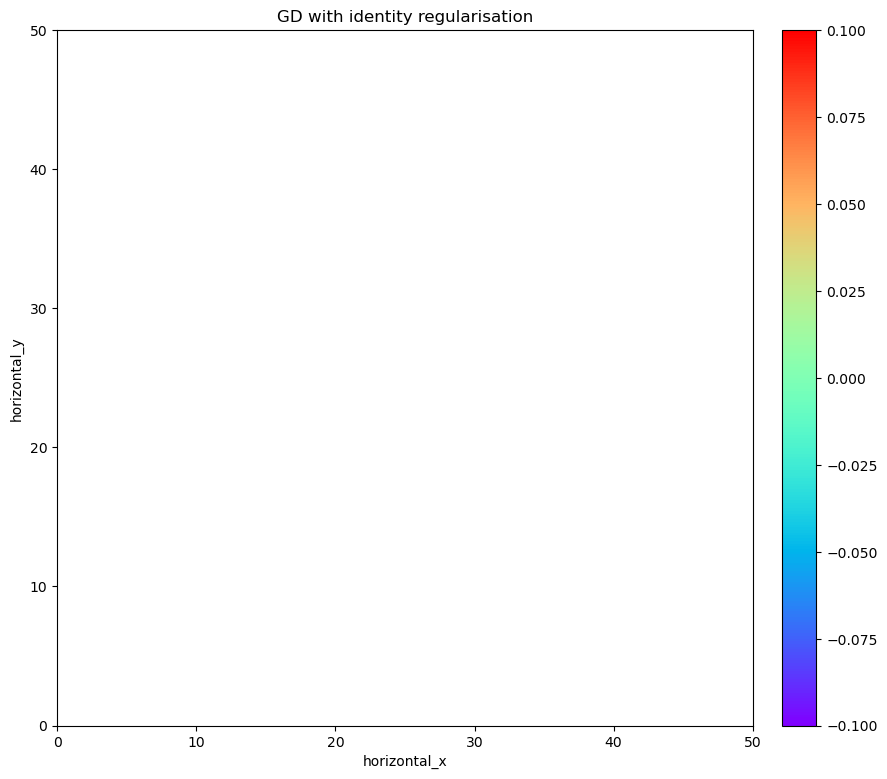

In [54]:
show2D([myGD_block], ['GD with identity regularisation'], cmap=cmap)